# 3. Height-difference correlations - 2D

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from surface_functions_2D import compute_heightdifference_correlations

## Dataframe computations

In [3]:
height_anisotropy_rows = []  # NEW

summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_2D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        heightheight_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for simulation_index, row in df.iterrows():
            t = row["t"]
            L = row["L"]
            phases = row["phases"]
                        
            phases_2d = []
            for ti in range(len(t)):
                phases_2d.append(phases[ti,:].reshape(L, L))
            phases_2d = np.array(phases_2d)
            
            hh_x, hh_y, heightheight = np.asarray(compute_heightdifference_correlations(phases_2d), dtype=float)

            # Exclude r = 0 and retain independent periodic separations
            rmax = L // 2 + 1
            hh_x_test = hh_x[:, 1:rmax]
            hh_y_test = hh_y[:, 1:rmax]

            # Normalized anisotropy at each time
            numerator_t = np.mean(
                np.abs(hh_x_test - hh_y_test),
                axis=1,
            )

            denominator_t = np.mean(
                0.5 * (hh_x_test + hh_y_test),
                axis=1,
            )

            anisotropy_t = np.divide(
                numerator_t,
                denominator_t,
                out=np.full_like(numerator_t, np.nan),
                where=denominator_t > 0,
            )

            # Store one row per simulation and time
            height_anisotropy_rows.extend(
                {
                    "typenoise": typenoise,
                    "delta": deltaname,
                    "L": L,
                    "simulation": simulation_index,
                    "t": time,
                    "anisotropy": anisotropy,
                }
                for time, anisotropy in zip(t, anisotropy_t)
            )
            
            heightheight_list.append(heightheight)

        # Avoid chained-assignment issues
        df = df.copy()
        df["heightheight"] = heightheight_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE HEIGHT-HEIGHT CORRELATION PER (K, L, T) ##
        # group by K, L, T and compute mean height-height correlation for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            heightheight_arrays = [np.asarray(r, dtype=float) for r in group["heightheight"]]
            mean_heightheight = np.mean(np.stack(heightheight_arrays, axis=0), axis=0)
            
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_heightheight": mean_heightheight,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


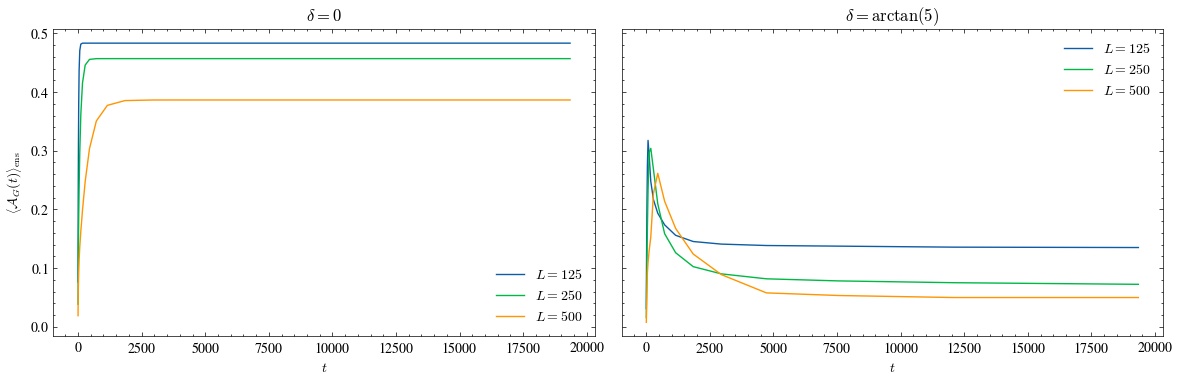

In [10]:
height_anisotropy_df = pd.DataFrame(height_anisotropy_rows)

typenoise = "Columnar"

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4),
    sharex=True,
    sharey=True,)

for ax, deltaname, delta_label in zip(
    axes,
    ["0", "atan5"],
    [r"$\delta=0$", r"$\delta=\arctan(5)$"],):
    plot_df = height_anisotropy_df[
        (height_anisotropy_df["typenoise"] == typenoise)
        & (height_anisotropy_df["delta"] == deltaname)]

    average_anisotropy = (
        plot_df
        .groupby(["L", "t"], as_index=False)["anisotropy"]
        .mean())

    for L, group in average_anisotropy.groupby("L"):
        group = group.sort_values("t")

        ax.plot(
            group["t"],
            group["anisotropy"],
            label=fr"$L={L}$",)

    ax.set_title(delta_label)
    ax.set_xlabel(r"$t$")
    ax.legend()

axes[0].set_ylabel(r"$\left\langle \mathcal{A}_G(t)\right\rangle_{\mathrm{ens}}$")

# fig.suptitle("Columnar noise — height-difference anisotropy")
plt.savefig("Figures/TFM/anisotropy_heightdifference.png", dpi=300)
fig.tight_layout()
plt.show()

In [7]:
avg_df_path = "../Simulations_2D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_heightheight"] = new_avg["mean_heightheight"]

avg_df.to_pickle(avg_df_path)

In [8]:
avg_df

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2,mean_heightheight
avg_id,,,,,,,,,,,
TimeDep_delta0_L125_K1.0_T20000_M216,TimeDep,0.000000,0,1.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",216,20000,"[0.0, 0.04343448929682738, 0.04561405423062608...","[0.0, 0.043435791113398625, 0.0456157441160759...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L250_K1.0_T20000_M94,TimeDep,0.000000,0,1.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",94,20000,"[0.0, 0.04347614686213526, 0.04566278674448989...","[0.0, 0.04347641937287254, 0.04566312057155149...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L500_K1.0_T20000_M23,TimeDep,0.000000,0,1.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",23,20000,"[0.0, 0.04344119832108249, 0.04568786433011544...","[0.0, 0.043441252625870494, 0.0456879636326816...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L1000_K1.0_T20000_M1,TimeDep,0.000000,0,1.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1,20000,"[0.0, 0.043480720390408865, 0.0456108179558477...","[0.0, 0.043480720390408865, 0.0456108179558477...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L125_K2.0_T20000_M200,TimeDep,0.000000,0,2.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",200,20000,"[0.0, 0.033203172546265855, 0.0346007981668795...","[0.0, 0.03320454911045176, 0.03460206299241868...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L250_K2.0_T20000_M53,TimeDep,0.000000,0,2.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",53,20000,"[0.0, 0.03319568700277479, 0.03461715560617203...","[0.0, 0.033195975535176156, 0.0346175497538397...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L500_K2.0_T20000_M12,TimeDep,0.000000,0,2.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",12,20000,"[0.0, 0.03321612641030911, 0.03459415654536505...","[0.0, 0.0332161980249859, 0.03459426408756459,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L125_K3.0_T20000_M200,TimeDep,0.000000,0,3.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",200,20000,"[0.0, 0.028263461141959656, 0.0293076055795248...","[0.0, 0.028264814105179756, 0.0293095116694587...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L250_K3.0_T20000_M138,TimeDep,0.000000,0,3.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",138,20000,"[0.0, 0.02826027900105302, 0.02933089558759107...","[0.0, 0.028260596888647727, 0.0293313768553479...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
